In [1]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
  os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ API key: ")

Enter your GROQ API key: ··········


In [2]:
!pip install langchain-groq langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.0 MB/s eta 0:00:00


In [8]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

In [4]:
llm=ChatGroq(model="openai/gpt-oss-120b",temperature=0,max_tokens=None,max_retries=3)

In [5]:
def multiply(a:int,b:int)->int:
   """Multiply 2 numbers a & b
   Args:
        a: first input
        b: second input
   """
   return a *b

def add(a:int,b:int)->int:
   """Addition of 2 numbers a & b
   Args:
        a: first input
        b: second input
   """
   return a + b

def division(a:int,b:int)->int:
   """divide 2 numbers a & b
   Args:
        a: first input
        b: second input
   """
   return a // b

tools =[multiply,add,division]


In [7]:
llm_with_tools = llm.bind_tools(tools)

In [10]:
from langgraph.graph import MessagesState

#system message
sys_msg=SystemMessage(content="You're an helpful assistant tasked for performing arthimetic operations such as addition, division & Multiplication")



In [11]:
def tool_assistant(state:MessagesState):
   return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [12]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image,display

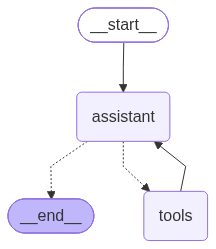

In [16]:
builder = StateGraph(MessagesState)

# define the nodes

builder.add_node("assistant",tool_assistant)
builder.add_node("tools",ToolNode(tools))


# define the edges

builder.add_edge(START,"assistant")
builder.add_conditional_edges("assistant",tools_condition)
builder.add_edge("tools","assistant")
builder.add_edge("assistant",END)
react_graph = builder.compile()
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [17]:
messages = [HumanMessage(content="Add 156789 and 234167. Multiply the output by 2. Divide the output by 4")]
messages =react_graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 156789 and 234167. Multiply the output by 2. Divide the output by 4
================================== Ai Message ==================================
Tool Calls:
  add (fc_fab1fd17-b47a-4795-b93e-a9a2a73e1112)
 Call ID: fc_fab1fd17-b47a-4795-b93e-a9a2a73e1112
  Args:
    a: 156789
    b: 234167
================================= Tool Message =================================
Name: add

390956
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_20f69540-b114-43b0-9a7f-0e83280268d8)
 Call ID: fc_20f69540-b114-43b0-9a7f-0e83280268d8
  Args:
    a: 390956
    b: 2
================================= Tool Message =================================
Name: multiply

781912
================================== Ai Message ==================================
Tool Calls:
  division (fc_7f590e16-489c-495c-a48d-fa26554705a7)
 Call ID: fc_7f590e16-489c-495c-a48d-fa2655

In [18]:
messages = [HumanMessage(content="Add it by 109")]
messages =react_graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add it by 109
================================== Ai Message ==================================

I’m not sure what number you’d like to add 109 to. Could you let me know the value you’d like to increase by 109?
